<a href="https://colab.research.google.com/github/Trickwillfrit/MFA/blob/main/notebooks/ENV501_Austria_Croatia_MFA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ENV-501 – Material Flow Analysis

## Austria & Croatia: PV and Wind Technologies

This notebook develops the data and modelling framework for a dynamic Material Flow Analysis (MFA) and material criticality assessment of solar PV and wind technologies in Austria and Croatia through 2050.

The analysis combines:
- historical renewable capacity data;
- national future deployment scenarios;
- technology and sub-technology market shares;
- material intensity coefficients;
- technology lifetimes and end-of-life flows;
- material criticality indicators.

The notebook is developed step by step to ensure that all assumptions, data transformations, and calculations are transparent and reproducible.



## 1. Load and inspect the raw IRENA datasets

Historical installed capacity data for solar PV and wind are obtained from IRENA and stored unchanged in the GitHub repository under `data/raw/`.

The datasets are loaded directly from GitHub and inspected before any transformation is applied. This step verifies the dataset structure, variable names, and units before the analysis begins.

In [ ]:
import pandas as pd

BASE_URL = "https://raw.githubusercontent.com/Trickwillfrit/MFA/main/data/raw"

pv_url = f"{BASE_URL}/solar_pv_capacity_irena_2026.csv"
wind_url = f"{BASE_URL}/wind_capacity_irena_2026.csv"

pv_raw = pd.read_csv(pv_url)
wind_raw = pd.read_csv(wind_url)

print("PV dataset loaded:", pv_raw.shape)
print("Wind dataset loaded:", wind_raw.shape)

PV dataset loaded: (3633, 4)
Wind dataset loaded: (3343, 4)


In [ ]:
print("PV columns:")
print(pv_raw.columns)

print("\nWind columns:")
print(wind_raw.columns)

print("\nPV preview:")
display(pv_raw.head())

print("\nWind preview:")
display(wind_raw.head())

PV columns:
Index(['Entity', 'Code', 'Year', 'Solar photovoltaic'], dtype='object')

Wind columns:
Index(['Entity', 'Code', 'Year', 'Wind'], dtype='object')

PV preview:


,Entity,Code,Year,Solar photovoltaic
0,Afghanistan,AFG,2017,0.0017
1,Afghanistan,AFG,2018,0.0017
2,Afghanistan,AFG,2019,0.0317
3,Afghanistan,AFG,2020,0.0317
4,Afghanistan,AFG,2021,0.0317



Wind preview:


,Entity,Code,Year,Wind
0,Afghanistan,AFG,2012,0.0001
1,Afghanistan,AFG,2013,0.0001
2,Afghanistan,AFG,2014,0.0001
3,Afghanistan,AFG,2015,0.0001
4,Afghanistan,AFG,2016,0.0001


## 2. Filter the raw IRENA datasets to Austria and Croatia

The raw IRENA datasets contain renewable capacity data for many countries.  
For this project, only Austria and Croatia are retained.

The original raw files remain unchanged in `data/raw/`; all filtering and transformations are performed in the notebook.

In [ ]:
countries = ["Austria", "Croatia"]

pv = pv_raw[pv_raw["Entity"].isin(countries)].copy()
wind = wind_raw[wind_raw["Entity"].isin(countries)].copy()

print("Filtered PV rows:", len(pv))
print("Filtered wind rows:", len(wind))

display(pv.head())
display(wind.head())

Filtered PV rows: 43
Filtered wind rows: 48


,Entity,Code,Year,Solar photovoltaic
223,Austria,AUT,2000,0.005
224,Austria,AUT,2001,0.007
225,Austria,AUT,2002,0.009
226,Austria,AUT,2003,0.023
227,Austria,AUT,2004,0.027


,Entity,Code,Year,Wind
168,Austria,AUT,2000,0.050
169,Austria,AUT,2001,0.067
170,Austria,AUT,2002,0.109
171,Austria,AUT,2003,0.322
172,Austria,AUT,2004,0.581


## 3. Check historical data coverage

Before transforming the datasets, the temporal coverage is checked for each country and technology.

This is important because the dynamic MFA requires a consistent historical capacity time series. Missing early years must therefore be identified explicitly rather than silently interpreted as zero capacity.

In [ ]:
pv_coverage = (
    pv.groupby("Entity")["Year"]
    .agg(["min", "max", "count"])
)

wind_coverage = (
    wind.groupby("Entity")["Year"]
    .agg(["min", "max", "count"])
)

print("PV historical coverage:")
display(pv_coverage)

print("\nWind historical coverage:")
display(wind_coverage)

PV historical coverage:


,min,max,count
Entity,,,
Austria,2000,2025,26
Croatia,2009,2025,17



Wind historical coverage:


,min,max,count
Entity,,,
Austria,2000,2025,26
Croatia,2004,2025,22


## 4. Standardize the historical capacity datasets

The PV and wind datasets use different names for their capacity variables.  
They are therefore converted into a common structure with the variables:

- `Country`
- `Code`
- `Year`
- `Technology`
- `Capacity_GW`

At this stage, only observed IRENA data are retained. Missing years before the first reported Croatian observations are not filled or interpreted.

In [ ]:
pv_hist = pv.rename(
    columns={
        "Entity": "Country",
        "Solar photovoltaic": "Capacity_GW"
    }
)

pv_hist["Technology"] = "Solar PV"


wind_hist = wind.rename(
    columns={
        "Entity": "Country",
        "Wind": "Capacity_GW"
    }
)

wind_hist["Technology"] = "Wind"


historical = pd.concat(
    [
        pv_hist[["Country", "Code", "Year", "Technology", "Capacity_GW"]],
        wind_hist[["Country", "Code", "Year", "Technology", "Capacity_GW"]]
    ],
    ignore_index=True
)

historical = historical.sort_values(
    ["Country", "Technology", "Year"]
).reset_index(drop=True)

display(historical.head(10))

print("Number of rows:", len(historical))

,Country,Code,Year,Technology,Capacity_GW
0,Austria,AUT,2000,Solar PV,0.005000
1,Austria,AUT,2001,Solar PV,0.007000
2,Austria,AUT,2002,Solar PV,0.009000
3,Austria,AUT,2003,Solar PV,0.023000
4,Austria,AUT,2004,Solar PV,0.027000
5,Austria,AUT,2005,Solar PV,0.021018
6,Austria,AUT,2006,Solar PV,0.022387
7,Austria,AUT,2007,Solar PV,0.024238
8,Austria,AUT,2008,Solar PV,0.030120
9,Austria,AUT,2009,Solar PV,0.048915


Number of rows: 91


## 5. Quality control of the historical dataset

Before using the historical capacity data in the MFA, basic consistency checks are performed.

The checks verify that:
- no values are missing;
- no duplicate country–technology–year observations exist;
- installed capacities are non-negative;
- the latest observations correspond to the expected 2025 values.

These checks help identify data-processing errors before further modelling.

In [ ]:
# Missing values
print("Missing values:")
print(historical.isna().sum())

# Duplicate observations
duplicates = historical.duplicated(
    subset=["Country", "Technology", "Year"]
).sum()

print("\nDuplicate country-technology-year observations:", duplicates)

# Negative capacity values
negative_capacity = (historical["Capacity_GW"] < 0).sum()

print("Negative capacity values:", negative_capacity)

# Latest available observations
latest_2025 = historical[historical["Year"] == 2025]

print("\n2025 installed capacity:")
display(latest_2025)

Missing values:
Country        0
Code           0
Year           0
Technology     0
Capacity_GW    0
dtype: int64

Duplicate country-technology-year observations: 0
Negative capacity values: 0

2025 installed capacity:


,Country,Code,Year,Technology,Capacity_GW
25,Austria,AUT,2025,Solar PV,10.295074
51,Austria,AUT,2025,Wind,4.292154
68,Croatia,HRV,2025,Solar PV,1.318800
90,Croatia,HRV,2025,Wind,1.375200


## 6. Visual inspection of historical installed capacity

The historical installed-capacity trajectories are plotted to visually inspect the data before introducing future deployment scenarios.

This provides an additional quality-control step and helps identify unusual discontinuities or potential data issues in the historical series.

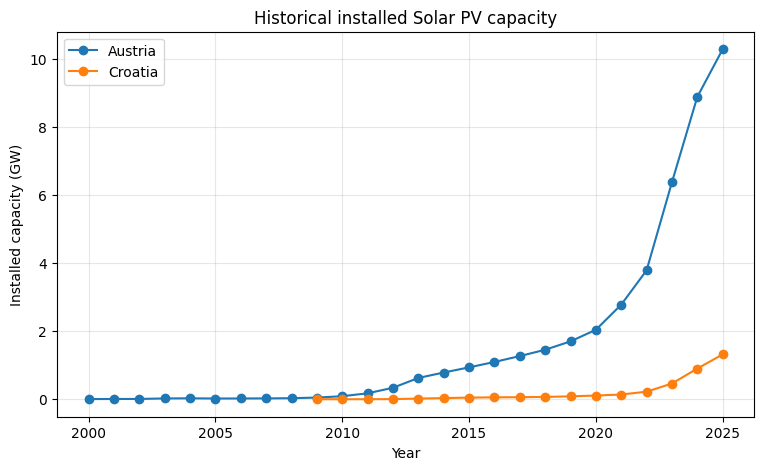

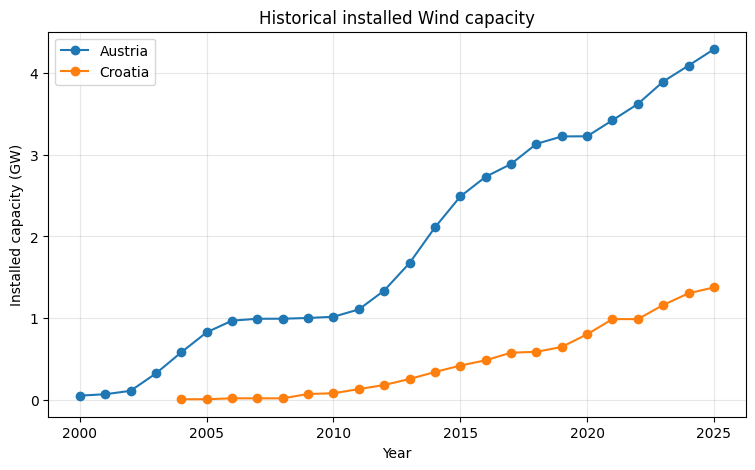

In [ ]:
import matplotlib.pyplot as plt

for technology in ["Solar PV", "Wind"]:

    plt.figure(figsize=(9, 5))

    for country in ["Austria", "Croatia"]:
        subset = historical[
            (historical["Country"] == country) &
            (historical["Technology"] == technology)
        ]

        plt.plot(
            subset["Year"],
            subset["Capacity_GW"],
            marker="o",
            label=country
        )

    plt.title(f"Historical installed {technology} capacity")
    plt.xlabel("Year")
    plt.ylabel("Installed capacity (GW)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 7. Define official future deployment anchors

Future installed-capacity pathways are based on official national energy-transition scenarios.

Historical observations through 2025 are kept separate from future scenario values.

For Austria, the baseline pathway uses the Umweltbundesamt Transition Scenario (2026).  
For Croatia, the baseline pathway uses the WAM scenario from the final updated National Energy and Climate Plan (NECP).

Only the official milestone years are entered at this stage. Annual values between milestones will be generated later using an explicitly documented interpolation method.

In [ ]:
future_anchors = pd.DataFrame([

    # Austria — Solar PV
    ["Austria", "Solar PV", 2030, 20.0],
    ["Austria", "Solar PV", 2040, 39.0],
    ["Austria", "Solar PV", 2050, 40.0],

    # Austria — Wind
    ["Austria", "Wind", 2030, 8.4],
    ["Austria", "Wind", 2040, 11.6],
    ["Austria", "Wind", 2050, 11.8],

    # Croatia — Solar PV
    ["Croatia", "Solar PV", 2030, 2.382],
    ["Croatia", "Solar PV", 2040, 4.860],
    ["Croatia", "Solar PV", 2050, 5.770],

    # Croatia — Wind
    ["Croatia", "Wind", 2030, 2.268],
    ["Croatia", "Wind", 2040, 3.563],
    ["Croatia", "Wind", 2050, 4.353],

], columns=[
    "Country",
    "Technology",
    "Year",
    "Capacity_GW"
])

display(future_anchors)

,Country,Technology,Year,Capacity_GW
0,Austria,Solar PV,2030,20.000
1,Austria,Solar PV,2040,39.000
2,Austria,Solar PV,2050,40.000
3,Austria,Wind,2030,8.400
4,Austria,Wind,2040,11.600
5,Austria,Wind,2050,11.800
6,Croatia,Solar PV,2030,2.382
7,Croatia,Solar PV,2040,4.860
8,Croatia,Solar PV,2050,5.770
9,Croatia,Wind,2030,2.268


## 8. Compare 2025 observed capacity with 2030 scenario targets

The observed 2025 installed capacities are compared with the official 2030 scenario anchors.

For each country and technology, the comparison calculates:

- the absolute capacity increase required between 2025 and 2030;
- the percentage increase relative to 2025;
- the compound annual growth rate (CAGR) required over the five-year period.

The CAGR is used only as a diagnostic indicator of deployment pace. It is **not** used to construct the annual capacity pathway.

In [ ]:
# Observed capacities in 2025
capacity_2025 = (
    historical[historical["Year"] == 2025]
    [["Country", "Technology", "Capacity_GW"]]
    .rename(columns={"Capacity_GW": "Capacity_2025_GW"})
)

# Official scenario targets for 2030
capacity_2030 = (
    future_anchors[future_anchors["Year"] == 2030]
    [["Country", "Technology", "Capacity_GW"]]
    .rename(columns={"Capacity_GW": "Capacity_2030_GW"})
)

# Combine observed 2025 values with 2030 targets
comparison_2030 = capacity_2025.merge(
    capacity_2030,
    on=["Country", "Technology"],
    how="inner"
)

# Absolute increase required
comparison_2030["Increase_2025_2030_GW"] = (
    comparison_2030["Capacity_2030_GW"]
    - comparison_2030["Capacity_2025_GW"]
)

# Percentage increase
comparison_2030["Increase_pct"] = (
    comparison_2030["Increase_2025_2030_GW"]
    / comparison_2030["Capacity_2025_GW"]
    * 100
)

# Compound annual growth rate over 5 years
comparison_2030["CAGR_pct"] = (
    (
        comparison_2030["Capacity_2030_GW"]
        / comparison_2030["Capacity_2025_GW"]
    ) ** (1 / 5) - 1
) * 100

display(comparison_2030.round(3))

,Country,Technology,Capacity_2025_GW,Capacity_2030_GW,Increase_2025_2030_GW,Increase_pct,CAGR_pct
0,Austria,Solar PV,10.295,20.000,9.705,94.268,14.204
1,Austria,Wind,4.292,8.400,4.108,95.706,14.372
2,Croatia,Solar PV,1.319,2.382,1.063,80.619,12.552
3,Croatia,Wind,1.375,2.268,0.893,64.921,10.524


## 9. Construct annual future capacity pathways

The official scenarios provide installed-capacity values only for selected milestone years rather than for every year.

To obtain the annual capacity series required by the dynamic MFA, cumulative installed capacity is interpolated linearly between:

- observed 2025 capacity and the 2030 scenario target;
- the 2030 and 2040 scenario targets;
- the 2040 and 2050 scenario targets.

Linear interpolation is used because it reproduces all official anchor values exactly while introducing the minimum additional assumptions about the shape of deployment between milestones.

The resulting annual values from 2026 onward are **modelled scenario values**, not observed capacities.

In [ ]:
import numpy as np

future_annual_list = []

for country in ["Austria", "Croatia"]:
    for technology in ["Solar PV", "Wind"]:

        # Observed 2025 starting point
        start_2025 = historical[
            (historical["Country"] == country) &
            (historical["Technology"] == technology) &
            (historical["Year"] == 2025)
        ]["Capacity_GW"].iloc[0]

        # Official future anchors
        anchors = future_anchors[
            (future_anchors["Country"] == country) &
            (future_anchors["Technology"] == technology)
        ][["Year", "Capacity_GW"]]

        # Add observed 2025 value to the anchor series
        anchors = pd.concat([
            pd.DataFrame({
                "Year": [2025],
                "Capacity_GW": [start_2025]
            }),
            anchors
        ]).sort_values("Year")

        # Annual timeline
        years = np.arange(2025, 2051)

        # Piecewise linear interpolation
        capacities = np.interp(
            years,
            anchors["Year"],
            anchors["Capacity_GW"]
        )

        temp = pd.DataFrame({
            "Country": country,
            "Technology": technology,
            "Year": years,
            "Capacity_GW": capacities
        })

        future_annual_list.append(temp)

future_annual = pd.concat(
    future_annual_list,
    ignore_index=True
)

display(future_annual.head(10))

,Country,Technology,Year,Capacity_GW
0,Austria,Solar PV,2025,10.295074
1,Austria,Solar PV,2026,12.236059
2,Austria,Solar PV,2027,14.177044
3,Austria,Solar PV,2028,16.118030
4,Austria,Solar PV,2029,18.059015
5,Austria,Solar PV,2030,20.000000
6,Austria,Solar PV,2031,21.900000
7,Austria,Solar PV,2032,23.800000
8,Austria,Solar PV,2033,25.700000
9,Austria,Solar PV,2034,27.600000


## 10. Validate the interpolated capacity pathway

The annual interpolated series is checked against the official 2030, 2040, and 2050 scenario anchors.

For each country and technology, the interpolated value should reproduce the corresponding official target exactly. Any non-zero difference would indicate an error in the pathway construction.

In [ ]:
anchor_check = future_annual.merge(
    future_anchors,
    on=["Country", "Technology", "Year"],
    suffixes=("_Interpolated", "_Official")
)

anchor_check["Difference_GW"] = (
    anchor_check["Capacity_GW_Interpolated"]
    - anchor_check["Capacity_GW_Official"]
)

display(anchor_check.round(6))

print(
    "Maximum absolute difference:",
    anchor_check["Difference_GW"].abs().max(),
    "GW"
)

,Country,Technology,Year,Capacity_GW_Interpolated,Capacity_GW_Official,Difference_GW
0,Austria,Solar PV,2030,20.000,20.000,0.0
1,Austria,Solar PV,2040,39.000,39.000,0.0
2,Austria,Solar PV,2050,40.000,40.000,0.0
3,Austria,Wind,2030,8.400,8.400,0.0
4,Austria,Wind,2040,11.600,11.600,0.0
5,Austria,Wind,2050,11.800,11.800,0.0
6,Croatia,Solar PV,2030,2.382,2.382,0.0
7,Croatia,Solar PV,2040,4.860,4.860,0.0
8,Croatia,Solar PV,2050,5.770,5.770,0.0
9,Croatia,Wind,2030,2.268,2.268,0.0


Maximum absolute difference: 0.0 GW


## 11. Combine historical observations and future scenario pathways

The historical IRENA observations and the modelled future capacity pathways are combined into a single deployment dataset.

To preserve transparency:

- values up to and including 2025 are classified as `Observed`;
- values from 2026 to 2050 are classified as `Modelled`;
- the observed 2025 value is retained as the transition point between historical data and future scenarios;
- the interpolated 2025 value is excluded to avoid duplication.

The early Croatian years that are absent from the IRENA dataset remain unresolved at this stage and are not automatically filled with zero.

In [ ]:
# Historical observed data
historical_deployment = historical.copy()

historical_deployment["Data_Status"] = "Observed"
historical_deployment["Scenario"] = "IRENA historical"


# Future modelled data: keep only 2026–2050
future_deployment = future_annual[
    future_annual["Year"] >= 2026
].copy()

future_deployment["Code"] = future_deployment["Country"].map({
    "Austria": "AUT",
    "Croatia": "HRV"
})

future_deployment["Data_Status"] = "Modelled"

future_deployment["Scenario"] = future_deployment["Country"].map({
    "Austria": "Transition Scenario 2026",
    "Croatia": "NECP WAM"
})


# Put columns in the same order
columns = [
    "Country",
    "Code",
    "Year",
    "Technology",
    "Capacity_GW",
    "Data_Status",
    "Scenario"
]

historical_deployment = historical_deployment[columns]
future_deployment = future_deployment[columns]


# Combine historical and future data
deployment = pd.concat(
    [historical_deployment, future_deployment],
    ignore_index=True
)

deployment = deployment.sort_values(
    ["Country", "Technology", "Year"]
).reset_index(drop=True)

display(deployment.head(10))

print("Total number of rows:", len(deployment))

,Country,Code,Year,Technology,Capacity_GW,Data_Status,Scenario
0,Austria,AUT,2000,Solar PV,0.005000,Observed,IRENA historical
1,Austria,AUT,2001,Solar PV,0.007000,Observed,IRENA historical
2,Austria,AUT,2002,Solar PV,0.009000,Observed,IRENA historical
3,Austria,AUT,2003,Solar PV,0.023000,Observed,IRENA historical
4,Austria,AUT,2004,Solar PV,0.027000,Observed,IRENA historical
5,Austria,AUT,2005,Solar PV,0.021018,Observed,IRENA historical
6,Austria,AUT,2006,Solar PV,0.022387,Observed,IRENA historical
7,Austria,AUT,2007,Solar PV,0.024238,Observed,IRENA historical
8,Austria,AUT,2008,Solar PV,0.030120,Observed,IRENA historical
9,Austria,AUT,2009,Solar PV,0.048915,Observed,IRENA historical


Total number of rows: 191


## 12. Final quality control of the deployment pathway

The combined deployment dataset is checked for consistency before it is used as an input to the dynamic MFA.

The checks verify that:

- no country–technology–year combination is duplicated;
- no installed-capacity values are negative;
- historical and future values connect correctly at 2025–2026;
- the full modelled pathway extends to 2050.

In [ ]:
# Check duplicates
duplicate_count = deployment.duplicated(
    subset=["Country", "Technology", "Year"]
).sum()

print("Duplicate observations:", duplicate_count)


# Check negative capacities
negative_count = (deployment["Capacity_GW"] < 0).sum()

print("Negative capacity values:", negative_count)


# Check transition around 2025–2026
transition_check = deployment[
    deployment["Year"].isin([2025, 2026])
].sort_values(
    ["Country", "Technology", "Year"]
)

print("\n2025–2026 transition:")
display(transition_check)


# Check final year
print("\nLatest year by country and technology:")
display(
    deployment.groupby(
        ["Country", "Technology"]
    )["Year"].max()
)

Duplicate observations: 0
Negative capacity values: 0

2025–2026 transition:


,Country,Code,Year,Technology,Capacity_GW,Data_Status,Scenario
25,Austria,AUT,2025,Solar PV,10.295074,Observed,IRENA historical
26,Austria,AUT,2026,Solar PV,12.236059,Modelled,Transition Scenario 2026
76,Austria,AUT,2025,Wind,4.292154,Observed,IRENA historical
77,Austria,AUT,2026,Wind,5.113723,Modelled,Transition Scenario 2026
118,Croatia,HRV,2025,Solar PV,1.318800,Observed,IRENA historical
119,Croatia,HRV,2026,Solar PV,1.531440,Modelled,NECP WAM
165,Croatia,HRV,2025,Wind,1.375200,Observed,IRENA historical
166,Croatia,HRV,2026,Wind,1.553760,Modelled,NECP WAM



Latest year by country and technology:


Country  Technology
Austria  Solar PV      2050
         Wind          2050
Croatia  Solar PV      2050
         Wind          2050
Name: Year, dtype: int64

## 13. Visualize the complete deployment pathways to 2050

The historical and future installed-capacity pathways are visualized for solar PV and wind.

Observed IRENA data are shown separately from the modelled scenario period to avoid presenting projected values as historical observations.

The figures provide the deployment backbone that will later be converted into technology and material flows in the dynamic MFA.

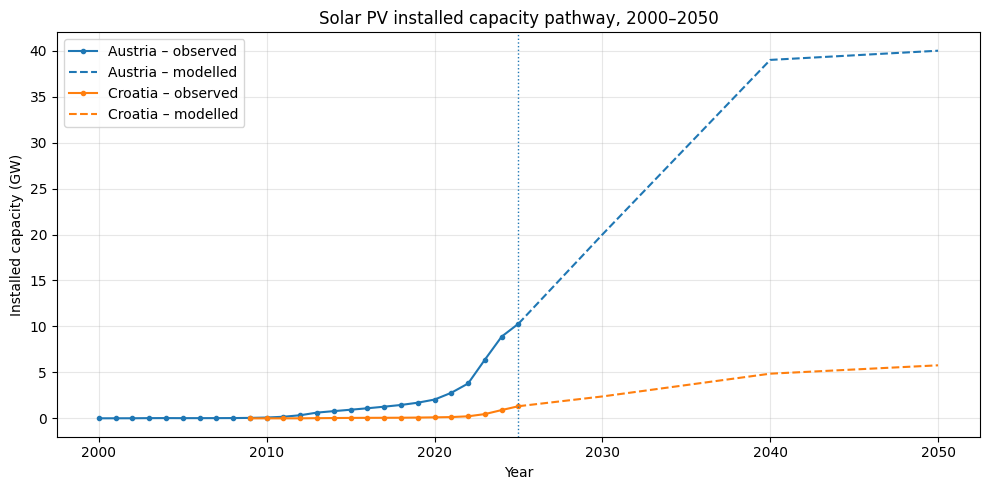

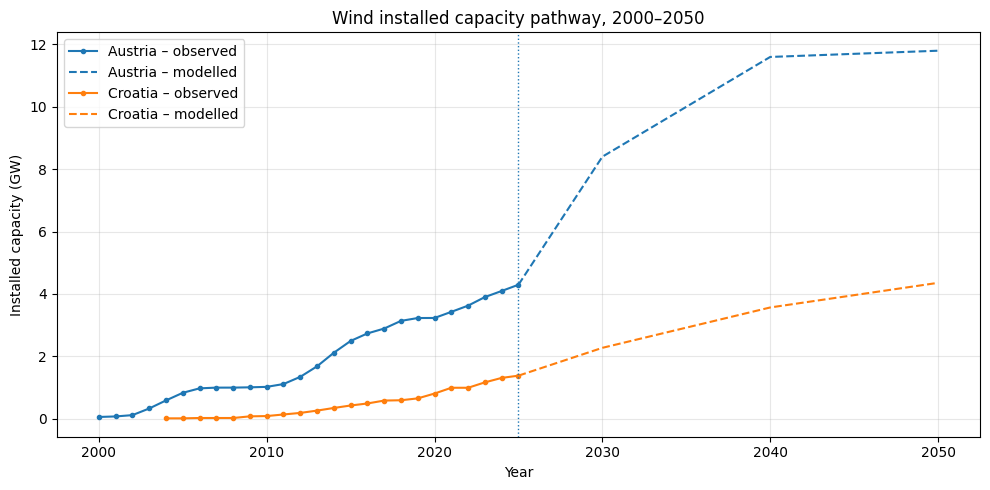

In [ ]:
# Use the default Matplotlib color cycle,
# but keep one consistent color for each country
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

country_colors = {
    "Austria": default_colors[0],
    "Croatia": default_colors[1]
}

for technology in ["Solar PV", "Wind"]:

    plt.figure(figsize=(10, 5))

    for country in ["Austria", "Croatia"]:

        observed = deployment[
            (deployment["Country"] == country) &
            (deployment["Technology"] == technology) &
            (deployment["Data_Status"] == "Observed")
        ]

        modelled = deployment[
            (deployment["Country"] == country) &
            (deployment["Technology"] == technology) &
            (deployment["Data_Status"] == "Modelled")
        ]

        # Historical observed data
        plt.plot(
            observed["Year"],
            observed["Capacity_GW"],
            marker="o",
            markersize=3,
            color=country_colors[country],
            label=f"{country} – observed"
        )

        # Add the observed 2025 point to the future line
        last_observed = observed[
            observed["Year"] == 2025
        ][["Year", "Capacity_GW"]]

        modelled_plot = pd.concat([
            last_observed,
            modelled[["Year", "Capacity_GW"]]
        ])

        # Future modelled pathway
        plt.plot(
            modelled_plot["Year"],
            modelled_plot["Capacity_GW"],
            linestyle="--",
            color=country_colors[country],
            label=f"{country} – modelled"
        )

    # Historical / modelled boundary
    plt.axvline(
        x=2025,
        linestyle=":",
        linewidth=1
    )

    plt.title(f"{technology} installed capacity pathway, 2000–2050")
    plt.xlabel("Year")
    plt.ylabel("Installed capacity (GW)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 14. Export the validated deployment pathway

The validated historical and future installed-capacity pathway is exported as a processed dataset.

This file serves as the deployment input for the subsequent dynamic MFA calculations. The original IRENA source files remain unchanged in `data/raw/`.

In [ ]:
deployment.to_csv(
    "deployment_pathway_2000_2050.csv",
    index=False
)

print("File exported successfully.")
print("Rows:", len(deployment))

File exported successfully.
Rows: 191


## 15. Define technology subcategories

The aggregate solar PV and wind capacity pathways must be disaggregated into technology subcategories before material demand can be calculated.

The main model follows the technology structure used in Martin del Campo et al. and the JRC raw-material demand framework.

Solar PV subtechnologies:
- crystalline silicon (c-Si);
- cadmium telluride (CdTe);
- copper indium gallium selenide (CIGS);
- amorphous silicon (a-Si).

Wind subtechnologies:
- direct-drive electrically excited synchronous generator (DD-EESG);
- direct-drive permanent magnet synchronous generator (DD-PMSG);
- gearbox permanent magnet synchronous generator (GB-PMSG);
- gearbox doubly-fed induction generator (GB-DFIG).

In the absence of sufficiently robust country-specific subtechnology shares, the European technology mix is applied to both Austria and Croatia. National differences therefore arise primarily from country-specific deployment pathways.

The subtechnology shares will be treated as an explicit modelling input and will be checked to ensure that they sum to 100% for every technology and year.

 ## 16. Define PV subtechnology-share anchors

PV subtechnology shares are based on the JRC High Demand Scenario (HDS), following the approach adopted by Martin del Campo et al.

The JRC baseline shares are:
- c-Si: 95.4%
- CdTe: 2.4%
- CIGS: 1.9%
- a-Si: 0.3%

The HDS assumes the following shares by 2050:
- c-Si: 77%
- CdTe: 10%
- CIGS: 10%
- a-Si: 3%

The same European technology mix is provisionally applied to Austria and Croatia.

Shares between the known JRC data points will later be obtained by linear interpolation.

Historical subtechnology shares before 2018 are treated separately and are not assumed at this stage.

In [ ]:
pv_share_anchors = pd.DataFrame([
    [2018, "c-Si", 0.954],
    [2018, "CdTe", 0.024],
    [2018, "CIGS", 0.019],
    [2018, "a-Si", 0.003],

    [2050, "c-Si", 0.770],
    [2050, "CdTe", 0.100],
    [2050, "CIGS", 0.100],
    [2050, "a-Si", 0.030]
],
columns=[
    "Year",
    "Subtechnology",
    "Share"
])

display(pv_share_anchors)

,Year,Subtechnology,Share
0,2018,c-Si,0.954
1,2018,CdTe,0.024
2,2018,CIGS,0.019
3,2018,a-Si,0.003
4,2050,c-Si,0.770
5,2050,CdTe,0.100
6,2050,CIGS,0.100
7,2050,a-Si,0.030


In [ ]:
pv_share_check = (
    pv_share_anchors
    .groupby("Year")["Share"]
    .sum()
)

display(pv_share_check)

,Share
Year,
2018,1.0
2050,1.0


## 17. Historical PV subtechnology-share assumption

Detailed annual numerical PV subtechnology shares for 2000–2017 are not reported in tabular form in the JRC source available for this analysis.

The JRC shows that the historical composition changed over time, particularly within thin-film technologies. Therefore, historical annual shares are not reconstructed from the figures without an explicit digitisation procedure.

For the baseline MFA, the 2018 JRC technology mix is provisionally applied to installations before 2018:

- c-Si: 95.4%
- CdTe: 2.4%
- CIGS: 1.9%
- a-Si: 0.3%

From 2018 to 2050, shares evolve linearly toward the JRC High Demand Scenario values.

This historical-share assumption will be treated as an uncertainty and can be tested in the sensitivity analysis.